# **Processing Data for Modeling**

**Overview**: 
This script processes and prepares data for modeling pedestrian counts in Melbourne. Several preprocessing steps are performed in other notebooks:

- *isochrone_urban_form_static.ipynb*
- *isochrone_urban_form_multiyear.ipynb*

**Outputs** (saved under `Output_data_from_processing_scripts`):

Visualizations

- Pedestrian count changes over time
- QQ plot of variables
- Kendall correlation and variable selection
- Sensor distributions on OpenStreetMap map

Key Files
- `kendall.csv` - Kendall correlation matrix for all urban features before removal of some variables
- `processed_melbourne_data_for_modeling.csv` – Includes all urban features and pedestrian counts for further analysis

Analysis Results

- Normality test results (confirming non-normality of data)

**Processing Steps**
1. **Data Preparation**:
   - Pedestrian counts
   - Urbanity data
   - Urban form features (for 15- and 5-min neighborhoods)
2. **Processing & Analysis**:
   - Data merging
   - Normality testing
   - Correlation analysis and variable selection visualization

**Start Date:** *Oct 21, 2024*  
**Last Update:** *Mar 31, 2025*  
**Authors:** *Kanaha Shoji & Benjamin Tarver*

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
from holidays import country_holidays
from functools import reduce
import os
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.dates import MonthLocator, DateFormatter
import scipy.stats as stats
import geopandas as gpd
from shapely.geometry import Point
import contextily as ctx
from scipy.stats import kstest
import seaborn as sns
from shapely.geometry import Point
import matplotlib.ticker as mticker

In [2]:
# Set base directory
base_dir = '/Users/shoji/Library/CloudStorage/OneDrive-epfl.ch/2025_03_Melbourne_walkability_study_final/urban-walkability-insights'
# Set directory to where open data are stored
open_data_dir = os.path.join(base_dir,'Open_datasets')
# Set directory for output from urban form multiyear scripts
uf_multi_dir = os.path.join(base_dir,'Output_data_from_urban_form_multiyear_scripts')
# Set directory for output from urban form scripts
uf_dir = os.path.join(base_dir,'Output_data_from_urban_form_scripts')

# set directory for output data
output_dir = os.path.join(base_dir,'Output_data_from_processing_scripts')

## **Data Preparation**

## Pedestrian counts

Pedestrain counts data downloaded from https://data.melbourne.vic.gov.au/explore/dataset/pedestrian-counting-system-monthly-counts-per-hour/information/

In [3]:
# Load the data
sensor_counts_mel = pd.read_csv(os.path.join(open_data_dir,'Pedestrian_Counting_System_Monthly_counts_per_hour_may_2009_to_14_dec_2022.csv'))

#### Checking changes over time

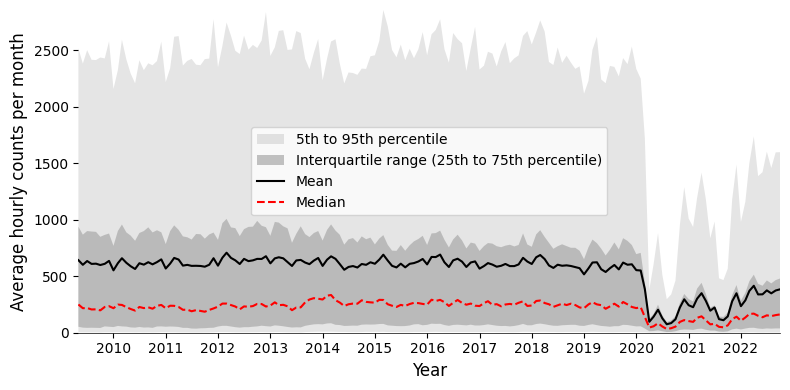

In [4]:
# Plot monthly stats
data = sensor_counts_mel.copy()
# Parse the Date_Time column if necessary
if data['Date_Time'].dtype == 'object':
    data['Date_Time'] = pd.to_datetime(data['Date_Time'], format='mixed')

data['Date_Time'].min() # Timestamp('2009-05-01 00:00:00')
start_date='2009-05-01'

# Group data by Year and Month
data['YearMonth'] = data['Date_Time'].dt.to_period('M')
monthly_stats = data.groupby('YearMonth')['Hourly_Counts'].agg(
    mean='mean',
    median='median',
    p95=lambda x: np.percentile(x, 95),
    p5=lambda x: np.percentile(x, 5),
    p25=lambda x: np.percentile(x, 25),
    p75=lambda x: np.percentile(x, 75)
).reset_index()

# Convert YearMonth back to datetime for plotting
monthly_stats['YearMonth'] = monthly_stats['YearMonth'].dt.to_timestamp()

plt.figure(figsize=(8, 4))
# Shaded areas for percentiles and IQR
plt.fill_between(
    monthly_stats['YearMonth'],
    monthly_stats['p5'],
    monthly_stats['p95'],
    color='darkgrey',edgecolor=None, # conflowerblue, lightblue, skyblue, silver
    alpha=0.3,
    label='5th to 95th percentile'
)
plt.fill_between(
    monthly_stats['YearMonth'],
    monthly_stats['p25'],
    monthly_stats['p75'],
    color='darkgrey',edgecolor=None,
    alpha=0.7,
    label='Interquartile range (25th to 75th percentile)'
)

# Lines for mean and median
plt.plot(
    monthly_stats['YearMonth'],
    monthly_stats['mean'],
    label='Mean',
    color='black',
    linestyle='-',
    linewidth=1.5
)
plt.plot(
    monthly_stats['YearMonth'],
    monthly_stats['median'],
    label='Median',
    color='red',
    linestyle='--',
    linewidth=1.5
)

# Formatting the plot
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average hourly counts per month', fontsize=12)
plt.legend(loc = 'center')
plt.grid(visible=False)

# Formatting the x-axis
plt.gca().xaxis.set_major_locator(MonthLocator(interval=12))  # Yearly ticks
plt.gca().xaxis.set_major_formatter(DateFormatter('%Y-%M'))  # Format ticks to show only year
plt.xticks()#rotation=90

# Force the x-axis to start from the specified date
plt.xlim(pd.Timestamp(start_date), monthly_stats['YearMonth'].max())
plt.gca().xaxis.set_major_locator(MonthLocator(bymonth=1, interval=1))  # Ticks every January
plt.gca().xaxis.set_major_formatter(DateFormatter('%Y'))  # Format ticks to show only the year
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_linewidth(0)
plt.gca().spines['bottom'].set_linewidth(0.5)
plt.margins(0)
plt.tight_layout()
plt.show()

#### Preprocessing pedestriain data for analysis 
* Pedestrian counts data before the pandemic is used
* Holiday info is added
* Sensor locations info is merged

Pedestrian counter sensors location data downloaded from https://melbournetestbed.opendatasoft.com/explore/dataset/pedestrian-counting-system-sensor-locations/export/

In [5]:
# Load data
sensor_locations_filtered = pd.read_csv(os.path.join(base_dir,'Output_data_from_isochrone_scripts','sensor_locations_with_graphs.csv'))

In [6]:
original_sensor_locations_filtered = sensor_locations_filtered.copy()
original_sensor_counts_mel = sensor_counts_mel.copy()

In [7]:
# Check for duplicates in all columns except 'Hourly_Counts'and 'ID'
duplicates = sensor_counts_mel.drop(['Hourly_Counts','ID'], axis=1).duplicated()
duplicate_rows = sensor_counts_mel[duplicates]
duplicate_rows

,ID,Date_Time,Year,Month,Mdate,Day,Time,Sensor_ID,Sensor_Name,Hourly_Counts
240683,205746,"September 01, 2010 12:00:00 AM",2010,September,1,Wednesday,0,1,Bourke Street Mall (North),77
240684,205747,"September 01, 2010 12:00:00 AM",2010,September,1,Wednesday,0,2,Bourke Street Mall (South),7
240685,205748,"September 01, 2010 12:00:00 AM",2010,September,1,Wednesday,0,3,Melbourne Central,24
240686,205749,"September 01, 2010 12:00:00 AM",2010,September,1,Wednesday,0,4,Town Hall (West),51
240687,205750,"September 01, 2010 12:00:00 AM",2010,September,1,Wednesday,0,5,Princes Bridge,31
...,...,...,...,...,...,...,...,...,...,...
252917,217964,"September 30, 2010 12:00:00 AM",2010,September,30,Thursday,0,14,Sandridge Bridge,184
252918,217965,"September 30, 2010 12:00:00 AM",2010,September,30,Thursday,0,15,State Library,225
252919,217966,"September 30, 2010 12:00:00 AM",2010,September,30,Thursday,0,16,Australia on Collins,107
252920,217967,"September 30, 2010 12:00:00 AM",2010,September,30,Thursday,0,17,Collins Place (South),120


September, 2010's hour is all 0, so only for this month, we are using data from https://www.pedestrian.melbourne.vic.gov.au/#date=26-02-2025&time=19 (Go to 'Download data' and click '2010 - Download data file (CSV, 700KB)')

In [8]:
# Replace September 2010 data with 2010 year data from the same source
# Load data
sensor_counts_2010 = pd.read_csv(os.path.join(open_data_dir,'2010.csv'))

In [9]:
sensor_counts_2010.columns

Index(['Date', 'Hour', 'State Library', 'Collins Place (South)',
       'Collins Place (North)', 'Flagstaff Station', 'Melbourne Central',
       'Town Hall (West)', 'Bourke Street Mall (North)',
       'Bourke Street Mall (South)', 'Australia on Collins',
       'Southern Cross Station', 'Victoria Point', 'New Quay',
       'Waterfront City', 'Webb Bridge', 'Princes Bridge',
       'Flinders St Station Underpass', 'Sandridge Bridge', 'Birrarung Marr'],
      dtype='object')

In [10]:
# Make 2010 data from wide to long to match sensor_counts_mel
sensor_columns = [col for col in sensor_counts_2010.columns if col not in ['Date', 'Hour']]
df_long_2010 = pd.melt(sensor_counts_2010, id_vars=['Date', 'Hour'], 
                       value_vars=sensor_columns, 
                       var_name='Sensor_Name', value_name='Hourly_Counts')
df_long_2010['Date_Time'] = pd.to_datetime(df_long_2010['Date'].astype(str) + ' ' + df_long_2010['Hour'].astype(str) + ':00', format='mixed')
df_long_2010 = df_long_2010.drop(columns=['Date', 'Hour'])

# Reorder and rename columns to match the sensor_counts format
df_long_2010 = df_long_2010[['Date_Time', 'Sensor_Name', 'Hourly_Counts']]
# Rename to match the sensor_counts format
df_long_2010['Sensor_Name'] = df_long_2010['Sensor_Name'].replace(
    'Flinders St Station Underpass', 'Flinders Street Station Underpass'
)

df_long_2010_9 = df_long_2010[df_long_2010['Date_Time'].dt.month == 9]

In [11]:
# Remove September 2010 data from sensor_counts_mel
sensor_counts_mel_woSep2010 = sensor_counts_mel[
    ~((sensor_counts_mel['Year'] == 2010) & (sensor_counts_mel['Month'] == 'September'))]

# Map Sensor_Name to ID
sensor_id_mapping = sensor_counts_mel[['Sensor_ID', 'Sensor_Name']].drop_duplicates()
df_long_2010_9 = df_long_2010_9.merge(sensor_id_mapping, on='Sensor_Name', how='left')
df_long_2010_9

,Date_Time,Sensor_Name,Hourly_Counts,Sensor_ID
0,2010-09-01 00:00:00,State Library,41.0,15
1,2010-09-01 01:00:00,State Library,21.0,15
2,2010-09-01 02:00:00,State Library,22.0,15
3,2010-09-01 03:00:00,State Library,6.0,15
4,2010-09-01 04:00:00,State Library,7.0,15
...,...,...,...,...
12955,2010-09-30 19:00:00,Birrarung Marr,NaN,7
12956,2010-09-30 20:00:00,Birrarung Marr,NaN,7
12957,2010-09-30 21:00:00,Birrarung Marr,NaN,7
12958,2010-09-30 22:00:00,Birrarung Marr,NaN,7


In [12]:
# Reorder columns and append September 2010 data to sensor_counts_mel
df_long_2010_9['Year'] = df_long_2010_9['Date_Time'].dt.year
df_long_2010_9['Month'] = df_long_2010_9['Date_Time'].dt.strftime('%B')
df_long_2010_9['Mdate'] = df_long_2010_9['Date_Time'].dt.day
df_long_2010_9['Day'] = df_long_2010_9['Date_Time'].dt.strftime('%A')
df_long_2010_9['Time'] = df_long_2010_9['Date_Time'].dt.hour

df_long_2010_9 = df_long_2010_9[['Sensor_ID', 'Date_Time', 'Year', 'Month', 'Mdate', 'Day', 'Time', 'Sensor_Name', 'Hourly_Counts']]
sensor_counts_mel_fixed = pd.concat([sensor_counts_mel_woSep2010, df_long_2010_9], ignore_index=True)

In [13]:
sensor_counts_mel_fixed['Month'].unique()

array(['November', 'August', 'September', 'October', 'May', 'July',
       'December', 'June', 'January', 'February', 'March', 'April'],
      dtype=object)

In [14]:
print(sensor_counts_mel_fixed[sensor_counts_mel_fixed['Sensor_Name'].str.contains('Russel', case=False, na=False)]['Sensor_ID'].unique())
print(sensor_locations_filtered[sensor_locations_filtered['Sensor_Description'].str.contains('Russel', case=False, na=False)]['Location_ID'].unique())

[21]
[21]


In [15]:
name_mapping = {
    "Swanston St - RMIT Building 14": "RMIT Building 14",
    "Swanston St - RMIT Building 80": "Building 80 RMIT",
    "Bourke St-Russell St (West)": "155-161 Russell Street",
    "Collins St (North)": "Collins Street (North)"
}
sensor_counts_mel_fixed['Sensor_Name'] = sensor_counts_mel_fixed['Sensor_Name'].replace(name_mapping)
location_counts_mel = sensor_counts_mel_fixed.merge(sensor_locations_filtered, 
                                    left_on=['Sensor_ID'], 
                                    right_on=['Location_ID'], 
                                    how='inner')

In [16]:
# Define the start and end dates for filtering
start_date = datetime(2009, 5, 1)
end_date = datetime(2019, 12, 31)

# Prepare holiday and weekend data
vic_holidays = country_holidays('AU', subdiv='VIC')[start_date:end_date]
date_range = pd.date_range(start=start_date, end=end_date, freq='D')
weekend_days = date_range[date_range.weekday >= 5]
weekend_dates = [date.date() for date in weekend_days]

In [17]:
# Add `Day_type` column to `location_counts_mel`
location_counts_mel.loc[:,'Date'] = pd.to_datetime(location_counts_mel['Date_Time'], format="%B %d, %Y %I:%M:%S %p")
location_counts_mel.loc[:,'Day_type'] = location_counts_mel.loc[:,'Date'].apply(
    lambda x: 1 if x.date() in vic_holidays or x.date() in weekend_dates else 0)
location_counts_mel.loc[:,'Usable Year'] = location_counts_mel.loc[:,'Year']
location_counts_mel.loc[:,'month'] = location_counts_mel.loc[:,'Date'].dt.month
location_counts_mel.loc[:,'day'] = location_counts_mel.loc[:,'Date'].dt.day
location_counts_mel.loc[:,'hour'] = location_counts_mel.loc[:,'Date'].dt.hour

In [18]:
# Filter data to include only the specified date range
location_counts_mel = location_counts_mel[location_counts_mel['Date'].between(start_date, end_date)]

In [19]:
location_counts_mel.drop(columns=['ID','Location_Type','Sensor_Name_y','Sensor_Name_x','Sensor_ID','Sensor_Description',
                                          'Closest Node','Closest Node Latitude','Closest Node Longitude',
                                          'Location','Installation_Date','Time','Day','Mdate','Month','Year','Date_Time'], inplace=True)
location_counts_mel

,Hourly_Counts,Location_ID,Latitude,Longitude,Graph_ID,Date,Day_type,Usable Year,month,day,hour
0,604.0,39,-37.813797,144.969957,G_015,2019-11-01 17:00:00,0,2019,11,1,17
1,216.0,37,-37.801071,144.967046,G_014,2019-11-01 17:00:00,0,2019,11,1,17
2,627.0,40,-37.809993,144.972276,G_043,2019-11-01 17:00:00,0,2019,11,1,17
3,774.0,36,-37.816525,144.961211,G_024,2019-11-01 17:00:00,0,2019,11,1,17
4,644.0,29,-37.819982,144.968729,G_012,2019-11-01 17:00:00,0,2019,11,1,17
...,...,...,...,...,...,...,...,...,...,...,...
3634923,351.0,14,-37.820112,144.962919,G_006,2010-09-30 19:00:00,0,2010,9,30,19
3634924,310.0,14,-37.820112,144.962919,G_006,2010-09-30 20:00:00,0,2010,9,30,20
3634925,277.0,14,-37.820112,144.962919,G_006,2010-09-30 21:00:00,0,2010,9,30,21
3634926,217.0,14,-37.820112,144.962919,G_006,2010-09-30 22:00:00,0,2010,9,30,22


## Urbanity data

About Urbanity data
* Winston Yap et al (2023) <a href = https://doi.org/10.1038/s42949-023-00125-w>Urbanity: automated modelling and analysis of multidimensional networks in cities</a>
* Winston Yap and Filip Biljecki (2023) <a href= https://doi.org/10.1038/s41597-023-02578-1> A global feature-rich network dataset of cities and dashboard for comprehensive urban analyses</a>
* Their code is available in Git: https://github.com/winstonyym/urbanity
* Urbanity data available in <a href= https://figshare.com/articles/dataset/Global_Urban_Network_Dataset/22124219> Figshare</a> which is mentioned in the 2nd paper (file name of the data used in this study is 'Melbourne_nodes_100m.geojson')

The following csv was created in QGIS by joining attributes by the neaest feature using the 'Join attrributes by nearest' tool. The steps takes in **QGIS** are:
- Load the data
    - open_data_dir + '/pedestrian-counting-system-sensor-locations.csv'
    - open_data_dir + '/Melbourne_nodes_100m.geojson'
- Open the 'Join attribute by nearest' tool
    - Got to 'Processing Toolbox'. If not found, go to 'View'> 'Pannels' then look for 'Processing Toolbox'<br>
![QGIS Processing Toolbox](Output_data_from_QGIS/QGIS_Processin_Toolbox_screenshot.png)


- Configure the Tool Parameters <br>
    - Input layer: select 'pedestrian-counting-system-sensor-locations.csv'
    - Input layer 2: select 'Melbourne_nodes_100m.geojson'

![Join Attributes by Nearest Parameters](Output_data_from_QGIS/QGIS_Join_Attributes_by_Nearest_parameters_screenshot.png)

- Run the tool
- Save the result as 'sensor_locations_urbanity_attribute_join_by_nearest_inQGIS.csv'

In [20]:
# Read in Urbanity CSV 
urbanity_mel = pd.read_csv(os.path.join(base_dir,'Output_data_from_QGIS/sensor_locations_urbanity_attribute_join_by_nearest_inQGIS.csv'))

In [21]:
# Drop unused data columns
urbanity_mel.drop(['Sensor_Name', 'Sensor_Description',
                 'Installation_Date','Note','Location_Type','Status','Direction_1','Direction_2','Latitude', 'Longitude','Location',
                 'feature_x','feature_y','nearest_x','nearest_y','distance','n',
                 'Civic','Commercial','Entertainment','Food','Healthcare','Institutional','Recreational','Social','node_id',
                 'x','y','osmid'], axis = 1, inplace = True) 
urbanity_mel

,Location_ID,Node Density,Street Length,Degree,Clustering,Clustering (Weighted),Closeness Centrality,Betweenness Centrality,Eigenvector Centrality,Katz Centrality,...,Green View Mean,Green View Stdev,Sky View Mean,Sky View Stdev,Building View Mean,Building View Stdev,Road View Mean,Road View Stdev,Visual Complexity Mean,Visual Complexity Stdev
0,2,3,758.813,1,0.0,0.0,0.014,0.001,False,0.004,...,0.179250,0.089996,0.052250,0.043817,0.210875,0.058394,0.236250,0.160054,1.920225,0.165915
1,4,1,201.053,3,0.0,0.0,0.010,0.000,False,0.003,...,0.213625,0.062328,0.063375,0.052230,0.200375,0.033895,0.276625,0.124819,1.913176,0.115402
2,6,15,1807.452,1,0.0,0.0,0.008,0.000,False,0.002,...,0.169333,0.104715,0.164000,0.077783,0.063778,0.051080,0.027667,0.083000,1.658925,0.159390
3,8,12,1996.103,3,0.0,0.0,0.011,0.000,False,0.004,...,0.127583,0.037843,0.245000,0.165735,0.129167,0.023935,0.152250,0.108668,1.789464,0.135108
4,10,7,1307.591,3,0.0,0.0,0.014,0.002,False,0.005,...,0.168500,0.218279,0.142750,0.099881,0.138500,0.112109,0.095000,0.072489,1.814472,0.166072
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,108,19,2133.888,4,0.0,0.0,0.008,0.000,False,0.002,...,0.108000,0.071447,0.128250,0.071500,0.465750,0.129193,0.069250,0.019990,1.679663,0.256467
104,112,6,799.758,3,0.0,0.0,0.010,0.000,False,0.004,...,0.205033,0.126213,0.183072,0.120001,0.139512,0.100044,0.232520,0.154496,1.826329,0.190920
105,114,21,1470.781,1,0.0,0.0,0.005,0.000,False,0.001,...,0.303318,0.085652,0.158932,0.089790,0.091886,0.096006,0.143909,0.063488,1.994927,0.175065
106,117,10,1408.908,1,0.0,0.0,0.014,0.001,False,0.004,...,0.168500,0.052565,0.320167,0.031587,0.256833,0.037812,0.098667,0.038526,1.819803,0.100994


## Urban form features (for 15/5- min neighborhoods)

#### Urban form features that changes annualy
* Building types counts
* Job counts
* Dwelling counts
* Parking counts
#### Urban form features without annual changes (due to data availability)
* Green area
* Tree area
* Walkable length
* Public transport access counts
* Lamp counts
* Public furniture counts
* Network stats

For Network statistics

Dictionary containing the following keys: (copied from https://osmnx.readthedocs.io/en/stable/user-reference.html)
* circuity_avg - see circuity_avg function documentation
* clean_intersection_count - see clean_intersection_count function documentation
* clean_intersection_density_km - clean_intersection_count per sq km
* edge_density_km - edge_length_total per sq km
* edge_length_avg - edge_length_total / m
* edge_length_total - see edge_length_total function documentation
* intersection_count - see intersection_count function documentation
* intersection_density_km - intersection_count per sq km
* k_avg - graph’s average node degree (in-degree and out-degree)
* m - count of edges in graph
* n - count of nodes in graph
* node_density_km - n per sq km
* self_loop_proportion - see self_loop_proportion function documentation
* street_density_km - street_length_total per sq km
* street_length_avg - street_length_total / street_segment_count
* street_length_total - see street_length_total function documentation
* street_segment_count - see street_segment_count function documentation
* streets_per_node_avg - see streets_per_node_avg function documentation
* streets_per_node_counts - see streets_per_node_counts function documentation
* streets_per_node_proportions - see streets_per_node_proportions function documentation

In [22]:
# Multi year variables # ------------------------------------------------------------------------
building_type_df = pd.read_csv(os.path.join(uf_multi_dir,'15min_melbourne_building_counts_df_all_years.csv')) 
building_type_df_5 = pd.read_csv(os.path.join(uf_multi_dir,'5min_melbourne_building_counts_df_all_years.csv'))
building_type_df.rename(columns = {'census_year': 'Usable Year', 'polygon_id':'Polygon'}, inplace=True)
building_type_df.columns = ['built_' + col if ('Polygon' not in col) and ('Usable Year' not in col) else col for col in building_type_df.columns]
building_type_df_5.rename(columns = {'census_year': 'Usable Year','polygon_id':'Polygon'}, inplace=True)
building_type_df_5.columns = ['built_' + col if ('Polygon' not in col) and ('Usable Year' not in col) else col for col in building_type_df_5.columns]

job_counts_df = pd.read_csv(os.path.join(uf_multi_dir,'15min_melbourne_job_counts_df_all_years_cat.csv')) 
job_counts_df_5 = pd.read_csv(os.path.join(uf_multi_dir,'5min_melbourne_job_counts_df_all_years_cat.csv'))
job_counts_df = job_counts_df[['Polygon', 'Total Jobs in Block', 'Usable Year']].rename(columns={'Total Jobs in Block': 'Job_count'})
job_counts_df_5 = job_counts_df_5[['Polygon', 'Total Jobs in Block', 'Usable Year']].rename(columns={'Total Jobs in Block': 'Job_count'})

dwelling_total_counts_df = pd.read_csv(os.path.join(uf_multi_dir,'15min_melbourne_total_dwellings.csv'))
dwelling_total_counts_df_5 = pd.read_csv(os.path.join(uf_multi_dir,'5min_melbourne_total_dwellings.csv')) 
dwelling_total_counts_df.rename(columns={'Total Dwellings': 'Dwelling_count'}, inplace = True)
dwelling_total_counts_df_5.rename(columns={'Total Dwellings': 'Dwelling_count'}, inplace = True)

parking_counts_df = pd.read_csv(os.path.join(uf_multi_dir,'15min_melbourne_parking_counts_df_all_years.csv')) 
parking_counts_df_5 = pd.read_csv(os.path.join(uf_multi_dir,'5min_melbourne_parking_counts_df_all_years.csv'))
parking_counts_df.rename(columns={'Residential Parking Spaces': 'Residential_parking', 'Commercial Parking Spaces': 'Commercial_parking', 'Private Parking Spaces': 'Private_parking', 'Total Parking Spaces': 'Parking_total'}, inplace = True)
parking_counts_df_5.rename(columns={'Residential Parking Spaces': 'Residential_parking', 'Commercial Parking Spaces': 'Commercial_parking', 'Private Parking Spaces': 'Private_parking', 'Total Parking Spaces': 'Parking_total'}, inplace = True)


# Static variables # ------------------------------------------------------------------------
area_df = pd.read_csv(os.path.join(uf_dir ,'15min_melbourne_area_df.csv')) 
area_df_5 = pd.read_csv(os.path.join(uf_dir ,'5min_melbourne_area_df.csv')) 
area_df_5.rename(columns={'area':'Isochrone_area'}, inplace=True)
area_df.rename(columns={'area':'Isochrone_area'}, inplace=True)

green_area_df = pd.read_csv(os.path.join(uf_dir ,'15min_melbourne_green_area_df.csv')) 
green_area_df_5 = pd.read_csv(os.path.join(uf_dir ,'5min_melbourne_green_area_df.csv')) 
green_area_df_5.rename(columns={'Total Area (m²)':'Green_area'}, inplace=True)
green_area_df.rename(columns={'Total Area (m²)':'Green_area'}, inplace=True)

tree_areas_df = pd.read_csv(os.path.join(uf_dir ,'15min_melbourne_tree_areas_df.csv')) 
tree_areas_df_5 = pd.read_csv(os.path.join(uf_dir ,'5min_melbourne_tree_areas_df.csv')) 
tree_areas_df_5.rename(columns={'Total Area (m²)':'Tree_area'}, inplace=True)
tree_areas_df.rename(columns={'Total Area (m²)':'Tree_area'}, inplace=True)

walkable_length_df = pd.read_csv(os.path.join(uf_dir ,'15min_melbourne_walkable_length_df.csv')) 
walkable_length_df_5 = pd.read_csv(os.path.join(uf_dir ,'5min_melbourne_walkable_length_df.csv')) 
walkable_length_df.rename(columns={'Total length (m)':'Walkable_path_length'}, inplace=True)
walkable_length_df_5.rename(columns={'Total length (m)':'Walkable_path_length'}, inplace=True)

public_transport_access_df = pd.read_csv(os.path.join(uf_dir ,'15min_melbourne_public_transport_access_df.csv')) 
public_transport_access_df_5 = pd.read_csv(os.path.join(uf_dir ,'5min_melbourne_public_transport_access_df.csv')) 
public_transport_access_df.rename(columns={'Total Transit Stop Count': 'Total_transit_stop_count', 'Bus Count': 'Bus_count', 'Tram Count': 'Tram_count', 'Train Count': 'Train_count'}, inplace=True)	
public_transport_access_df_5.rename(columns={'Total Transit Stop Count': 'Total_transit_stop_count', 'Bus Count': 'Bus_count', 'Tram Count': 'Tram_count', 'Train Count': 'Train_count'}, inplace=True)	

lamp_counts_df = pd.read_csv(os.path.join(uf_dir ,'15min_melbourne_lamp_counts_df.csv')) 
lamp_counts_df_5 = pd.read_csv(os.path.join(uf_dir ,'5min_melbourne_lamp_counts_df.csv')) 
lamp_counts_df.rename(columns={'Lamps in Block': 'Lamp_count'}, inplace = True)
lamp_counts_df_5.rename(columns={'Lamps in Block': 'Lamp_count'}, inplace = True)

public_furniture_counts_df = pd.read_csv(os.path.join(uf_dir ,'15min_melbourne_public_seating_df.csv')) 
public_furniture_counts_df_5 = pd.read_csv(os.path.join(uf_dir ,'5min_melbourne_public_seating_df.csv')) 
public_furniture_counts_df.rename(columns={'Seats in Block': 'Bench_count'}, inplace = True)
public_furniture_counts_df_5.rename(columns={'Seats in Block': 'Bench_count'}, inplace = True)

osmnx15min_stats = pd.read_csv(os.path.join(uf_dir,'15min_melbourne_network_stats_df.csv'))
osmnx5min_stats = pd.read_csv(os.path.join(uf_dir,'5min_melbourne_network_stats_df.csv'))

In [23]:
# Create array of years as well as an array to store polygon IDs which have missing data
years = np.arange(2009,2020).astype('str')
bad_polys = []

In [24]:
# Rename columns of data for variables whose spatial extent is confined in five or fifteen minute isochrone
fifteenminuters = [building_type_df, area_df, green_area_df, tree_areas_df, walkable_length_df, lamp_counts_df,
                public_transport_access_df, dwelling_total_counts_df,
                parking_counts_df, public_furniture_counts_df,job_counts_df, osmnx15min_stats
                ]

fiveminuters = [building_type_df_5, area_df_5, green_area_df_5, tree_areas_df_5, walkable_length_df_5, lamp_counts_df_5,
                public_transport_access_df_5, dwelling_total_counts_df_5,
                parking_counts_df_5, public_furniture_counts_df_5,job_counts_df_5,osmnx5min_stats
                ]

for df5 in fiveminuters:
    df5.columns = ['5_' + col if ('Polygon' not in col) and ('Usable Year' not in col) else col for col in df5.columns]

for df15 in fifteenminuters:
    df15.columns = ['15_' + col if ('Polygon' not in col) and ('Usable Year' not in col) else col for col in df15.columns]

#### Urban Form features info for 15 min neighborhood data

In [25]:
# Merge time-independent data
features_15min = reduce(lambda left, right: pd.merge(left, right, on=['Polygon'], how='outer'), 
                     [area_df, green_area_df, tree_areas_df, walkable_length_df, public_transport_access_df, 
                      lamp_counts_df, public_furniture_counts_df, osmnx15min_stats])
years_arr = []
for year in years:
    # Create years column that can be used for merging temporally variant data accurately
    copydf = features_15min.copy()
    copydf['Usable Year'] = year
    years_arr.append(copydf)
features_15min = pd.concat(years_arr, ignore_index=True)

for df in [features_15min, building_type_df, job_counts_df,dwelling_total_counts_df,parking_counts_df]:
    df['Usable Year'] = df['Usable Year'].astype(int)

# Merge time-dependent data
features_15min = reduce(lambda left, right: pd.merge(left, right, on=['Polygon', 'Usable Year'], how='outer'), 
                     [features_15min,building_type_df,job_counts_df, dwelling_total_counts_df,parking_counts_df])

features_15min[['15_Green_area','15_Tree_area','15_Walkable_path_length']] = features_15min[['15_Green_area','15_Tree_area','15_Walkable_path_length']].round(2)

#### Urban Form features info for 5 min neighborhood data

In [26]:
# Merging time-independent data
features_5min = reduce(lambda left, right: pd.merge(left, right, on=['Polygon'], how='outer'), 
                     [area_df_5, green_area_df_5, tree_areas_df_5, walkable_length_df_5, public_transport_access_df_5, 
                      lamp_counts_df_5, public_furniture_counts_df_5, osmnx5min_stats])
years_arr = []
for year in years:
    copydf = features_5min.copy()
    copydf['Usable Year'] = year
    years_arr.append(copydf)
features_5min = pd.concat(years_arr, ignore_index=True)

for df in [features_5min, building_type_df_5, job_counts_df_5,dwelling_total_counts_df_5,parking_counts_df_5]:
    df['Usable Year'] = df['Usable Year'].astype(int)

# Merging time-dependent data after year column creation
features_5min = reduce(lambda left, right: pd.merge(left, right, on=['Polygon', 'Usable Year'], how='outer'), 
                     [features_5min, building_type_df_5,job_counts_df_5, dwelling_total_counts_df_5,parking_counts_df_5])
features_5min[['5_Green_area','5_Tree_area','5_Walkable_path_length']] = features_5min[['5_Green_area','5_Tree_area','5_Walkable_path_length']].round(2)

#### Density 

In [27]:
features_15min['15_Intersection_density'] = features_15min['15_intersection_count'] / features_15min['15_Isochrone_area']
features_5min['5_Intersection_density'] = features_5min['5_intersection_count'] / features_5min['5_Isochrone_area']

features_15min['15_Lamp_density'] = features_15min['15_Lamp_count'] / features_15min['15_Isochrone_area']
features_15min['15_Bench_density'] = features_15min['15_Bench_count'] / features_15min['15_Isochrone_area']
features_15min['15_Tree_density'] = features_15min['15_Tree_area'] / features_15min['15_Isochrone_area']

features_5min['5_Lamp_density'] = features_5min['5_Lamp_count'] / features_5min['5_Isochrone_area']
features_5min['5_Bench_density'] = features_5min['5_Bench_count'] / features_5min['5_Isochrone_area']
features_5min['5_Tree_density'] = features_5min['5_Tree_area'] / features_5min['5_Isochrone_area']

features_5min['15_Edge_density'] = features_15min['15_m'] / features_15min['15_Isochrone_area']
features_5min['5_Edge_density'] = features_5min['5_m'] / features_5min['5_Isochrone_area']

#### Calculate physical diversity
Based on National Index diversity definition https://www.epa.gov/system/files/documents/2023-10/epa_sld_3.0_technicaldocumentationuserguide_may2021_0.pdf

In [28]:
# Mix of commercial uses

# D2b_E8MixA = -E/(ln(8))

# E=(E8_Ret/TotEmp)*ln(E8_Ret/TotEmp) +
# (E8_Off/TotEmp)*ln(E8_Off/TotEmp) +
# (E8_Ind/TotEmp)*ln(E8_Ind/TotEmp) +
# (E8_Svc/TotEmp)*ln(E8_Svc/TotEmp) +
# (E8_Ent/TotEmp)*ln(E8_Ent/TotEmp) +
# (E8_Ed/TotEmp)*ln(E8_Ed/TotEmp) +
# (E8_Hlth/TotEmp)*ln(E8_Hlth/TotEmp) +
# (E8_Pub/TotEmp)*ln(E8_Pub/TotEmp)

# For building based physical mix
def calculate_NWI_commercial_mix_built(df, source='built', isochroneMin=5):
    E8_columns = [
        col for col in df.columns 
        if col.startswith(f'{isochroneMin}_{source}') and col not in{f'{isochroneMin}_{source}_Household_count',
                                                                     f'{isochroneMin}_{source}_Unused_count',
                                                                     f'{isochroneMin}_{source}_Parking_count',}]
    TotEmp = df[f'{isochroneMin}_Job_count']
    # Check if TotEmp has zeros and handle accordingly
    if (TotEmp == 0).any():
        print("Warning: TotEmp contains zeros. Adjusting to avoid division by zero.")
    
    epsilon = 1e-10  # Add a small constant to avoid division by zero and log(0)
    TotEmp = TotEmp + epsilon

    E = sum((df[col] / TotEmp) * np.log((df[col] + epsilon) / TotEmp) for col in E8_columns)

    # Calculate D2b_E8MixA
    df[f'{isochroneMin}_{source}_D2b_E8MixA'] = -E / np.log(8)

In [29]:
# Mix of all uses

# D2a_EpHHm = -A/(ln(N))

# A = (HH/TotAct)*ln(HH/TotAct) +
# (E5_Ret/TotAct)*ln(E5_Ret/TotAct) +
# (E5_Off/TotAct)*ln(E5_Off/TotAct) +
# (E5_Ind/TotAct)*ln(E5_Ind/TotAct) +
# (E5_Svc/TotAct)*ln(E5_Svc/TotAct) +
# (E5_Ent/TotAct)*ln(E5_Ent/TotAct)
# TotAct = TotEmp + HH

# N= number of activity categories (employment or households)
# with count > 0.

# For building based physical mix
def calculate_NWI_all_mix_built(df, source='built', isochroneMin=5):
    excluded_patterns = ['Education_count', 'Health_care_count', 'Public_Administration_count',
                         'Unused_count','Parking_count']  # Patterns to exclude
    E5_columns = [
        col for col in df.columns 
        if col.startswith(f'{isochroneMin}_{source}') and 
        not any(pattern in col for pattern in excluded_patterns)]
    TotEmp = df[f'{isochroneMin}_Job_count']
    HH = df[f'{isochroneMin}_{source}_Household_count']
    TotAct = TotEmp + HH
    # Check if TotEmp has zeros and handle accordingly
    if (TotAct == 0).any():
        print("Warning: TotEmp contains zeros. Adjusting to avoid division by zero.")
    
    epsilon = 1e-10  # Add a small constant to avoid division by zero and log(0)
    TotAct = TotAct + epsilon

    A = (HH/TotAct) * np.log(HH/TotAct) + sum((df[col] / TotAct) * np.log((df[col] + epsilon) / TotAct) for col in E5_columns)

    # Calculate D2a_EpHHm
    df[f'{isochroneMin}_{source}_D2a_EpHHm'] = -A / np.log(5)

In [30]:
# Building based physical mix
# 15 min isochrone
calculate_NWI_commercial_mix_built(df= features_15min, source= 'built', isochroneMin= 15)
calculate_NWI_all_mix_built(df= features_15min, source= 'built', isochroneMin= 15)

# # 5 min isochrone
calculate_NWI_commercial_mix_built(df= features_5min, source= 'built', isochroneMin= 5)
calculate_NWI_all_mix_built(df= features_5min, source= 'built', isochroneMin= 5)

/Users/shoji/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


## **Processing & Analysis**

### Data merging
#### Merge Weather and Pedestrian counts

In [31]:
# Read in CSVs 
weather_all_yrs = pd.read_csv(os.path.join(open_data_dir,'era5_melbourne.csv'))

In [32]:
ped_weather = pd.merge(weather_all_yrs, location_counts_mel, on=['Usable Year', 'month', 'day', 'hour'], how='inner')
ped_weather.drop_duplicates(inplace=True)

### Merge above and Urbanity data

In [33]:
# Merge ped and weather data with Urbanity data
ped_weather_urbanity = pd.merge(ped_weather, urbanity_mel, on=['Location_ID'], how='inner')
ped_weather_urbanity.drop_duplicates(inplace=True)

### Merge above and Urban form features

In [34]:
# Merge ped weather urbanity data with OSMNx data
ped_weather_urbanity = ped_weather_urbanity.rename(columns={'Graph_ID': 'Polygon'})
mel_df = reduce(lambda left, right: pd.merge(left, right, on=['Polygon', 'Usable Year'], how='outer'), 
                     [ped_weather_urbanity, features_15min, features_5min])

In [35]:
# Removing rows where Hourly_Counts is NaN or -1
mel_df = mel_df.rename(columns={'Hourly_Counts': 'pedestrian_count'})
mel_df.dropna(subset=['pedestrian_count'], inplace=True)
mel_df = mel_df.loc[mel_df['pedestrian_count'].astype(int) != -1]
mel_df.drop(columns=['Polygon', '15_streets_per_node_counts', 
                           '15_streets_per_node_proportions','5_streets_per_node_counts', 
                           '5_streets_per_node_proportions'], inplace=True)
mel_df.drop_duplicates(inplace=True)
print(mel_df.head())

   temperature  total_precipitation  wind_speed  cloud_cover  \
0         11.7                0.190        5.06         0.93   
1         13.5                0.143        4.51         1.00   
2         14.2                0.148        3.58         1.00   
3         14.1                0.065        2.38         1.00   
4         14.7                0.403        1.72         1.00   

                  time  Usable Year  month  day  hour  pedestrian_count  ...  \
0  2009-05-01 00:00:00         2009    5.0  1.0   0.0              52.0  ...   
1  2009-05-01 01:00:00         2009    5.0  1.0   1.0              34.0  ...   
2  2009-05-01 02:00:00         2009    5.0  1.0   2.0              19.0  ...   
3  2009-05-01 03:00:00         2009    5.0  1.0   3.0              14.0  ...   
4  2009-05-01 04:00:00         2009    5.0  1.0   4.0              15.0  ...   

   5_Commercial_parking  5_Parking_total  5_Intersection_density  \
0                   0.0              0.0                0.001523  

In [36]:
nunique = pd.DataFrame(mel_df.nunique())
print(nunique[nunique.iloc[:, 0] < 5])

                                     0
Day_type                             2
Degree                               3
Clustering                           3
Clustering (Weighted)                4
Eigenvector Centrality               1
PageRank                             1
5_Train_count                        2
5_built_Public Administration_count  3


In [37]:
# Remove variables not used 
unwanted_list = [
    # Repetitive info regarding time
    'Date','time',

    # Unique count less than 5
    'Degree','Clustering','Clustering (Weighted)','Eigenvector Centrality','PageRank','5_Train_count',
    
    # Individual amenity
    '15_Retail_count','15_Office_count','15_Industry_count','15_Service_count','15_Unused_count',
    '15_Entertainment_count','15_Education_count','15_Health care_count','15_Public administration_count',

    '5_Retail_count','5_Office_count','5_Industry_count','5_Service_count','5_Unused_count',
    '5_Entertainment_count','5_Education_count','5_Health care_count','5_Public administration_count',

    '15_Residential_parking','5_Residential_parking',
    '15_Private_parking','5_Private_parking',
    '15_Commercial_parking','5_Commercial_parking',

    # Individual amenity (used for diversity calculation)
    '15_built_Retail_count', '15_built_Office_count','15_built_Industry_count', '15_built_Service_count',
    '15_built_Entertainment_count', '15_built_Education_count', '15_built_Health care_count', '15_built_Public Administration_count',
    '15_built_Household_count', '15_built_Unused_count','15_built_Parking_count',

    '5_built_Retail_count', '5_built_Office_count','5_built_Industry_count', '5_built_Service_count',
    '5_built_Entertainment_count', '5_built_Education_count','5_built_Health care_count','5_built_Public Administration_count',
    '5_built_Household_count', '5_built_Unused_count','5_built_Parking_count',

    # Repetitve info regarding infrastructure 
    '15_Isochrone_area','5_Isochrone_area',

    # Repetitive info regarding infrastructure (Density is used instead)
    '15_Lamp_count','5_Lamp_count','15_Bench_count','5_Bench_count', '15_Tree_area','5_Tree_area', 

    # Repetitive info or difficult to interpret for interventions purpuse regarding networks
    'Node Density','Street Length','Footprint Proportion','Perimeter Total','Perimeter Stdev',
    'Footprint Stdev','Complexity Mean','Complexity Stdev', 
    '15_edge_length_total','15_streets_per_node_avg','15_intersection_count',
    '15_street_length_total','15_street_segment_count','15_street_length_avg',
    '15_circuity_avg','15_self_loop_proportion',         
    '5_edge_length_total','5_streets_per_node_avg','5_intersection_count',
    '5_street_length_total','5_street_segment_count','5_street_length_avg',
    '5_circuity_avg','5_self_loop_proportion','5_n','15_n','5_m','15_m','15_k_avg','5_k_avg',

    # Repetitive info regarding view (Mean is used instead)
    'Building View Stdev','Green View Stdev','Road View Stdev','Sky View Stdev','Visual Complexity Stdev']

mel_df_final= mel_df.drop(columns=unwanted_list, errors='ignore')

In [38]:
# Rename columns
replacement_map = {
    "built_D2b_E8MixA": "Amenity_diversity",
    "built_D2a_EpHHm": "Building_use_diversity",
    "Usable Year": "Year",
    "PopSum":"Population_total",
}

def clean_column_name(col_name):
    for key, value in replacement_map.items():         # Replace specific substrings based on the mapping
        if key in col_name:
            col_name = col_name.replace(key, value)
    if col_name[0].isdigit():         # Handle cases starting with a number
        parts = col_name.split("_", 1)  # Split into number and rest
        if len(parts) > 1:
            col_name = parts[0] + "_" + parts[1].capitalize()  # Capitalize after "_"
        else:
            col_name = col_name.capitalize()  # Fallback
    else:
        # Handle cases starting with a letter
        col_name = col_name.capitalize()
    return col_name

mel_df_final.columns = [clean_column_name(col) for col in mel_df_final.columns]

### Normality testing

In [39]:
mel_df_final.fillna(0, inplace=True)

####  Histogram

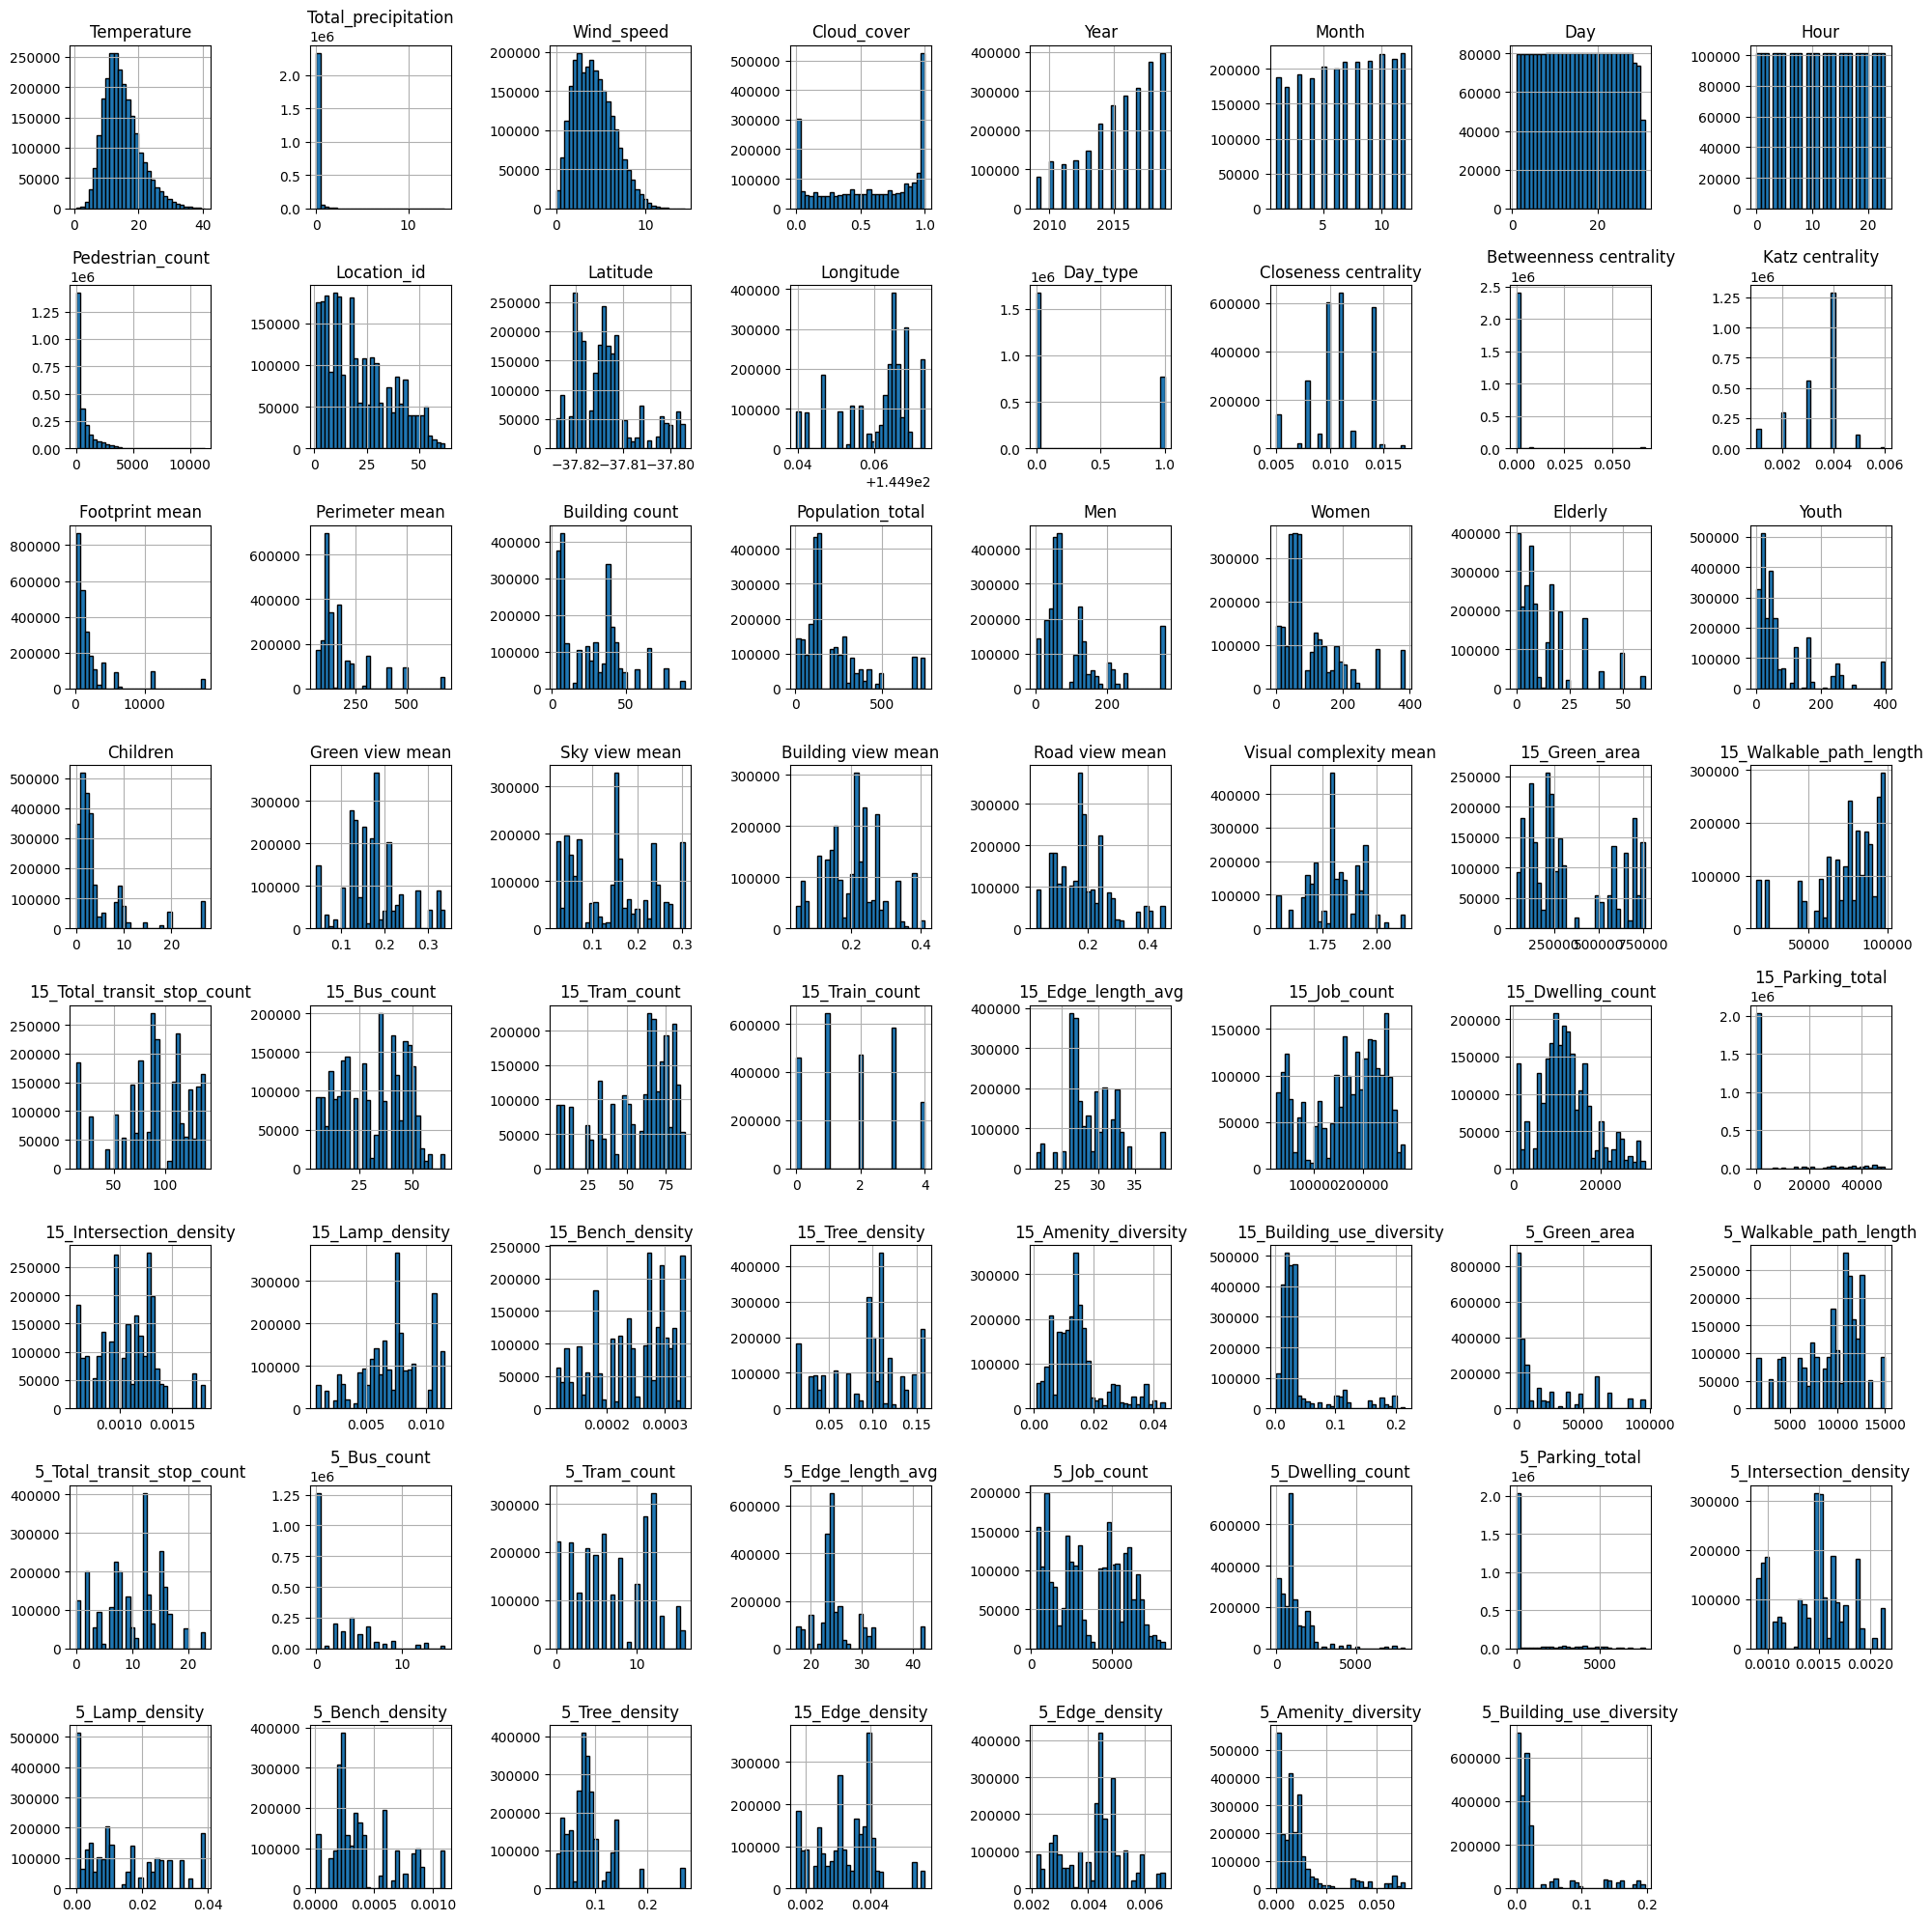

In [40]:
mel_df_final.hist(bins=31, figsize=(20, 20), edgecolor='black')
plt.tight_layout()
plt.show()

#### QQ plots

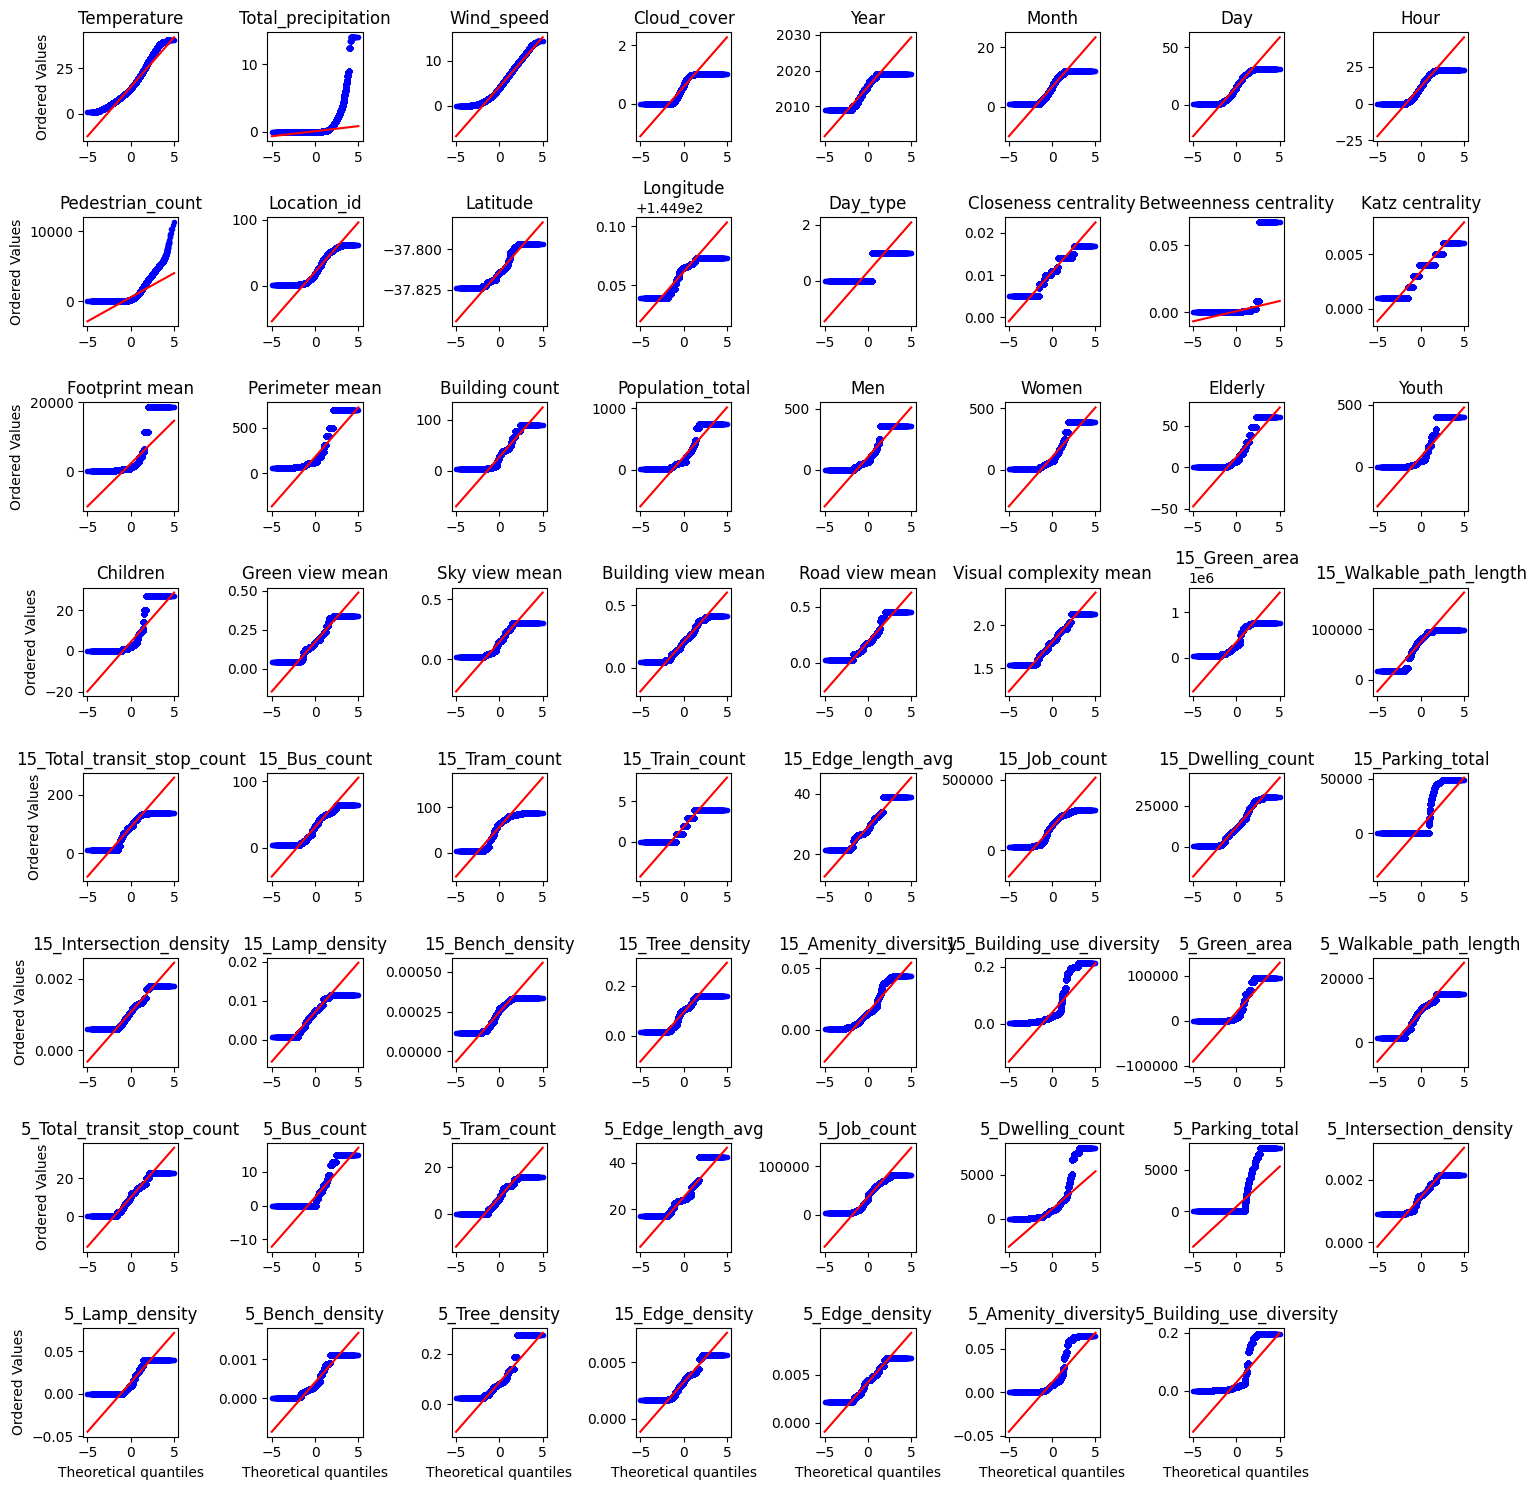

In [41]:
# Plot Q-Q plots for visual inspection
plt.figure(figsize=(15, 15))

num_cols = 8  # Adjust the number of columns as needed
num_rows = (len(mel_df_final.columns) + num_cols - 1) // num_cols

for i, col in enumerate(mel_df_final.columns, 1):
    ax = plt.subplot(num_rows, num_cols, i)
    stats.probplot(mel_df_final[col], dist="norm", plot=plt)
    plt.title(f'{col}')
    plt.gca().get_lines()[0].set_markersize(3)
    
    # Remove x-axis labels except for the bottom plots
    if i <= (num_rows - 1) * num_cols:
        ax.set_xlabel('')
    
    # Remove y-axis labels except for the leftmost plots
    if i % num_cols != 1:
        ax.set_ylabel('')

plt.tight_layout()
plt.show()

####  Shapiro-Wilk test

In [42]:
# Perform Shapiro-Wilk test for normality on each variable
results = {}
normal_variables = []

for col in mel_df_final.columns:
    stat, p_value = stats.shapiro(mel_df_final[col])
    results[col] = p_value

# Check the results
for col, p_value in results.items():
    if p_value >= 0.05:
        normal_variables.append((col, p_value))

# Display the results
if normal_variables:
    print("The following variables are normal:")
    for var, p_value in normal_variables:
        print(f"- {var}: p-value = {p_value:.5f}")
else:
    print("None of the variables are normal.")

/Users/shoji/opt/anaconda3/lib/python3.9/site-packages/scipy/stats/_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


None of the variables are normal.


#### Anderson-Darling test

In [43]:
# Perform Anderson-Darling test for normality on each variable
results = {}
normal_variables = []

for col in mel_df_final.columns:
    result = stats.anderson(mel_df_final[col], dist='norm')
    results[col] = {
        "statistic": result.statistic,
        "critical_values": result.critical_values,
        "significance_level": result.significance_level
    }

# Check the results
for col, res in results.items():
    is_normal = False
    for sl, cv in zip(res["significance_level"], res["critical_values"]):
        if res["statistic"] <= cv:
            is_normal = True
            break
    if is_normal:
        normal_variables.append(col)

# Display the results
if normal_variables:
    print("The following variables are normal:")
    for var in normal_variables:
        print(f"- {var}")
else:
    print("None of the variables are normal.")

None of the variables are normal.


#### Kolmogorov-Smirnov test

In [44]:
# Perform Kolmogorov-Smirnov test for normality on each variable
results = {}
normal_variables = []

for col in mel_df_final.columns:
    stat, p_value = kstest(mel_df_final[col], 'norm')
    results[col] = p_value

# Check the results
for col, p_value in results.items():
    if p_value >= 0.05:
        normal_variables.append((col, p_value))

# Display the results
if normal_variables:
    print("The following variables are normal:")
    for var, p_value in normal_variables:
        print(f"- {var}: p-value = {p_value:.5f}")
else:
    print("None of the variables are normal.")

None of the variables are normal.


### Correlation analysis and variable selection visualization
#### Kendall correlation analysis

In [45]:
ck = mel_df_final.corr(method='kendall') # quantifies strength of association according to rank, robust

In [46]:
ck.to_csv(os.path.join(output_dir,'kendall.csv'))
ck = pd.read_csv(os.path.join(output_dir,'kendall.csv'), index_col=0)

#### Variable selection visualiztion

In [47]:
variables = ck.columns.tolist()
# Create a DataFrame with a default 'Unknown' category
cat_df = pd.DataFrame({ # categorization_df
    'Variable': variables,
    'Category': ['Unknown'] * len(variables)})

# Automatically assign categories based on variable name patterns and manually assigned the rest
cat_df.loc[cat_df['Variable'].str.contains('centrality|mean|isochrone|Walkable|_Node |_Edge|edge_length|Degree_|Streets_|segment|Intersection|Circuity_|Self_loop',  case=False), 'Category'] = 'Network'
cat_df.loc[cat_df['Variable'].str.contains('Building count|Footprint|Perimeter|Complexity', case=False), 'Category'] = 'Buildings'
cat_df.loc[cat_df['Variable'].str.contains('_Job_|_dwelling', case=False), 'Category'] = 'Population'
cat_df.loc[cat_df['Variable'].str.contains('Green_|Lamp_|parking|Bench|Tree_|Green_', case=False), 'Category'] = 'Infrastructure'
cat_df.loc[cat_df['Variable'].str.contains('Year|Month|Hour|Day|Hoour|Day_type', case=False), 'Category'] = 'Time'
cat_df.loc[cat_df['Variable'].str.contains('Temperature|humidity|Wind_|precipitation|loud_cover', case=False), 'Category'] = 'Weather'
cat_df.loc[cat_df['Variable'].str.contains('View|Visual', case=False), 'Category'] = 'Visual index'
cat_df.loc[cat_df['Variable'].str.contains('train|tram|bus|transit', case=False), 'Category'] = 'Public transport'
cat_df.loc[cat_df['Variable'].str.contains('Pedestrian|Location_id|Latitude|Longitude', case=False), 'Category'] = 'Sensor'
cat_df.loc[cat_df['Variable'].str.contains('Population|Elderly|Youth|Children|Women', case=False), 'Category'] = 'Population'
cat_df.loc[cat_df['Variable'] == 'Men', 'Category'] = 'Population'
cat_df.loc[cat_df['Variable'].str.contains('Amenity_diversity|Building_use_diversity', case=False), 'Category'] = 'Urban use diversity'

In [48]:
def split_long_labels(labels_dict, max_line_length=11):
    wrapped_labels = {}
    
    for key, label in labels_dict.items():
        # Initialize the list to hold parts of the wrapped label
        wrapped_label = []
        current_line = []
        current_length = 0
        
        # Split the label by spaces and underscores
        words = label.replace('_', ' ').split()
        
        for word in words:
            # Check if adding the next word exceeds the max line length
            if current_length + len(word) + 1 <= max_line_length:  # +1 for space
                current_line.append(word)
                current_length += len(word) + 1
            else:
                # Join the current line and add to the wrapped label
                wrapped_label.append(' '.join(current_line))
                # Start a new line
                current_line = [word]
                current_length = len(word) + 1
        
        # Add the last line
        if current_line:
            wrapped_label.append(' '.join(current_line))
        
        # Join the wrapped label with newline characters
        wrapped_labels[key] = '\n'.join(wrapped_label)
    
    return wrapped_labels

In [49]:
custom_category_order = [
    'Sensor','Time','Weather','Population',
     'Urban use diversity', 'Buildings',
    'Network','Public transport','Infrastructure',
    'Visual index']

In [59]:
def varSelectionPlot(removed_variables, 
                     categorization_df=cat_df,
                     variables=variables, 
                     threshold=0.8, showAllCorr=True, 
                     custom_category_order = custom_category_order,
                     ck=ck,
                     alphaLevel=0.4, fontSize=9, nodeSize=800, lineW=2,edgealpha=0.7,weightmultiplier=0.6,
                     removed_alphaLevel = 0.2,
                     maxRows = [4, 5, 4, 4, 4, 2, 2, 8,6,1,8,10,7,2,2,14,2,5],
                     figsizeXY=(14, 20),MaxLineL=14,boxAnchor=(0.9, 0.9)):
    
    # Reorder variables: remaining first, then removed
    remaining_variables = [var for var in variables if var not in removed_variables]
    key_variables_order = ['Pedestrian_count', 'Location_id','Longitude',
                           'Year','Month','Day', 'Hour', 
                           'Temperature','Relative_humidity','Wind_speed',
                           'Total_precipitation','Building count','Footprint mean',
                           '5_Dwelling_count','15_Dwelling_count',
                           '5_Job_count','15_Job_count',
                           'Population_total','Children','Elderly','Youth','5_Walkable_path_length','15_Walkable_path_length',
                           '5_Isochrone_area','15_Isochrone_area',
                           '5_Edge_length_avg','5_Intersection_density','15_Intersection_density',
                           '5_Edge_density','15_Edge_length_avg','15_Edge_density',
                           'Betweenness centrality','Closeness centrality','Katz centrality',
                           '5_Total_transit_stop_count','15_Total_transit_stop_count', 
                            '5_Bus_count','15_Bus_count','5_Tram_count','15_Tram_count','15_Train_count',
                           '5_Bench_density','15_Bench_density',
                           '5_Tree_density','15_Tree_density',
                            '5_Lamp_density','15_Lamp_density',
                            '5_Parking_total', '15_Parking_total',
                            '5_Green_area','15_Green_area',
                             '5_Building_use_diversity','5_Amenity_diversity' ,
                            '15_Building_use_diversity','15_Amenity_diversity',
                            'Building view mean', 'Green view mean','Sky view mean',
                              'Road view mean', 'Visual complexity mean'  ]

    # Combine all variables (ignoring remaining vs removed distinction)
    all_variables = [var for var in variables if var in remaining_variables + removed_variables]

    # Sort all variables directly based on key_variables_order
    ordered_variables = sorted(all_variables, key=lambda x: key_variables_order.index(x) if x in key_variables_order else len(key_variables_order))

    # Categorization dictionary
    categorization_dict = pd.Series(categorization_df['Category'].values, index=categorization_df['Variable']).to_dict()
    categorization_dict_ordered = {var: categorization_dict[var] for var in ordered_variables if var in categorization_dict}

    # Create a graph
    G_ordered = nx.Graph()

    # Add nodes with category information as node attributes
    for var in ordered_variables:
        G_ordered.add_node(var, category=categorization_dict_ordered[var])

    # Add edges based on correlation threshold
    for var1 in ordered_variables:
        for var2 in ordered_variables:
            if var1 != var2:
                correlation_value = ck.loc[var1, var2]  # Using the correlation matrix
                if abs(correlation_value) > threshold:
                    G_ordered.add_edge(var1, var2, weight=correlation_value)

    # Color categories
    viridis = plt.get_cmap('viridis', len(custom_category_order))

    category_colors = {category: mcolors.to_hex(viridis(i)) for i, category in enumerate(custom_category_order)}

    if not showAllCorr:
        edges_between_remaining = [(u, v) for u, v in G_ordered.edges() if u in remaining_variables and v in remaining_variables]
        edge_weights = [abs(G_ordered[u][v]['weight']) for u, v in edges_between_remaining]
    else:
        node_colors = [category_colors[categorization_dict_ordered[node]] for node in G_ordered.nodes()]
        edge_weights = [abs(G_ordered[u][v]['weight']) for u, v in G_ordered.edges()]

    edge_thickness = [weight * weightmultiplier for weight in edge_weights]
    
    def generate_layout_with_custom_category_order_and_maxRows(G, categorization_dict, removed_variables, custom_category_order, maxRows, padding=1):
        """
        Generate a layout where nodes are distributed across rows with custom lengths, 
        and the order of nodes is first based on custom category order, then within each category based 
        on kept and removed variables.
        
        Parameters:
        - G: The graph
        - categorization_dict: Dictionary of variable categories
        - removed_variables: List of removed variables
        - custom_category_order: List of categories in the desired order
        - maxRows: List containing the number of nodes for each row
        - padding: Vertical spacing between rows
        """
        # Step 1: Reorder variables by custom category order and kept/removed status
        ordered_variables = []
        for category in custom_category_order:  # Loop through categories in the specified custom order
            category_vars = [var for var in G.nodes if categorization_dict.get(var) == category]

            # Sort category variables based on key_variables_order
            sorted_category_vars = sorted(category_vars, key=lambda x: key_variables_order.index(x) if x in key_variables_order else len(key_variables_order))
            
            # Add to the ordered list
            ordered_variables.extend(sorted_category_vars)
        
        # Step 2: Generate layout based on maxRows
        pos = {}
        y_offset = 0  # Start position for the first row
        row_idx = 0   # Index for the current row

        # Loop through each row and assign nodes
        for row_length in maxRows:
            row_nodes = ordered_variables[sum(maxRows[:row_idx]):sum(maxRows[:row_idx+1])]  # Get nodes for this row
            for idx, node in enumerate(row_nodes):
                pos[node] = (idx % row_length, y_offset)  # Positioning nodes horizontally
            
            # Move to the next row
            y_offset -= padding
            row_idx += 1  # Increment the row index
        return pos

    # Create the categorization dictionary
    categorization_dict_ordered = {var: categorization_dict[var] for var in ordered_variables if var in categorization_dict}

    # Generate the layout with the updated row lengths and order
    pos_ordered = generate_layout_with_custom_category_order_and_maxRows(G_ordered, categorization_dict_ordered, removed_variables, custom_category_order, maxRows=maxRows)

    # Draw the graph with the updated layout
    plt.figure(figsize =figsizeXY)

    # Draw remaining nodes with fill color
    remaining_nodes = [node for node in G_ordered.nodes() if node not in removed_variables]
    node_colors_remaining = [category_colors[categorization_dict_ordered[node]] for node in remaining_nodes]
    nx.draw_networkx_nodes(G_ordered, pos_ordered, nodelist=remaining_nodes, node_color=node_colors_remaining, node_size=nodeSize, alpha=alphaLevel)

    # Draw removed nodes with border only (no fill)
    nx.draw_networkx_nodes(G_ordered, pos_ordered, 
                        nodelist=removed_variables, 
                        node_color='none', edgecolors=[category_colors[categorization_dict_ordered[node]] for node in removed_variables],
                        node_size=nodeSize, linewidths=lineW, alpha= removed_alphaLevel)
    # Draw edges
    if not showAllCorr:
        nx.draw_networkx_edges(G_ordered, pos_ordered, edgelist=edges_between_remaining, width=edge_thickness, edge_color='gray', alpha=edgealpha)
    else:
        nx.draw_networkx_edges(G_ordered, pos_ordered, width=edge_thickness, edge_color='gray', alpha=edgealpha)

    # Draw labels
    variable_labels = {node: node for node in G_ordered.nodes()}
    wrapped_labels = split_long_labels(variable_labels, max_line_length= MaxLineL) # Split long labels into multiple lines
    nx.draw_networkx_labels(G_ordered, pos_ordered, labels=wrapped_labels, font_size=fontSize)

    # Remove plot frame
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['left'].set_visible(False)
    plt.gca().spines['bottom'].set_visible(False)
    plt.gca().xaxis.set_ticks([])
    plt.gca().yaxis.set_ticks([])

    # Add legend
    handles = []
    for category, color in category_colors.items():
        handles.append(plt.Line2D([0], [0], marker='o', color='w', label=category,
                                markerfacecolor=color, markersize=10, alpha=0.8))
    plt.legend(handles=handles, title='Categories', bbox_to_anchor=boxAnchor, fontsize=12)
# Make background transparent
    fig = plt.gcf()
    fig.patch.set_alpha(0.0)
    plt.gca().patch.set_alpha(0.0)
    plt.show()


In [58]:
removed_variables = ['Men','Women','Perimeter mean','Latitude',#'Longitude',
                    '15_Edge_density','5_Edge_density','15_Edge_length_avg',
                    'Katz centrality','15_Train_count',
                    '15_Parking_total',
                    '15_Amenity_diversity','5_Amenity_diversity',
                      ]

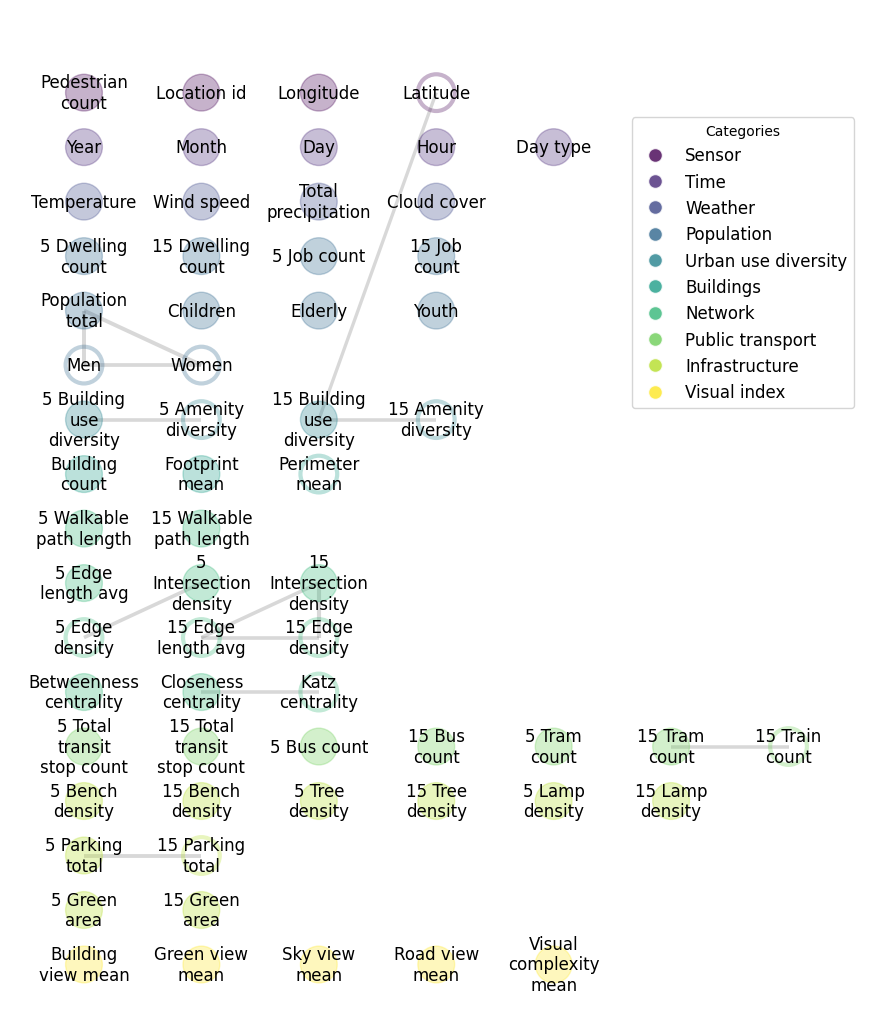

In [60]:
varSelectionPlot(removed_variables= removed_variables, # removed_variables= removed_variables_updated
                     categorization_df = cat_df,
                     variables = variables, # use if we have some variables that we don't want to visualize
                     threshold = 0.8, showAllCorr = True, 
                     custom_category_order= custom_category_order,
                     ck=ck,
                     alphaLevel = 0.3, fontSize = 12, nodeSize= 700, lineW= 3,
                     maxRows = [4, 5, 4, 4, 4, 2, 4, 3, 2,3,3,3,7,6,2,2,5],figsizeXY=(11, 13),
                     MaxLineL=12,boxAnchor=(1, 0.9),
                     removed_alphaLevel = 0.3,
                     edgealpha=0.3,weightmultiplier=3)# edges based on the original correlation matrix

In [11]:
print(ck['15_Tram_count']['15_Train_count'])

0.8452035874997613


In [56]:
print(ck['15_Building_use_diversity']['15_Amenity_diversity'])
print(ck['5_Building_use_diversity']['5_Amenity_diversity'])

0.8596969392090686
0.8793748015687004


In [57]:
print(ck['15_Building_use_diversity']['Latitude'])
print(ck['15_Amenity_diversity']['Latitude'])

0.8019938716868645
0.7773751358897864


Columns with more than one absolute correlation value greater than 0.8:
Latitude
Closeness centrality
Katz centrality
Population_total
Men
Women
15_Tram_count
15_Train_count
15_Edge_length_avg
15_Parking_total
15_Intersection_density
15_Amenity_diversity
15_Building_use_diversity
5_Parking_total
5_Intersection_density
15_Edge_density
5_Edge_density
5_Amenity_diversity
5_Building_use_diversity


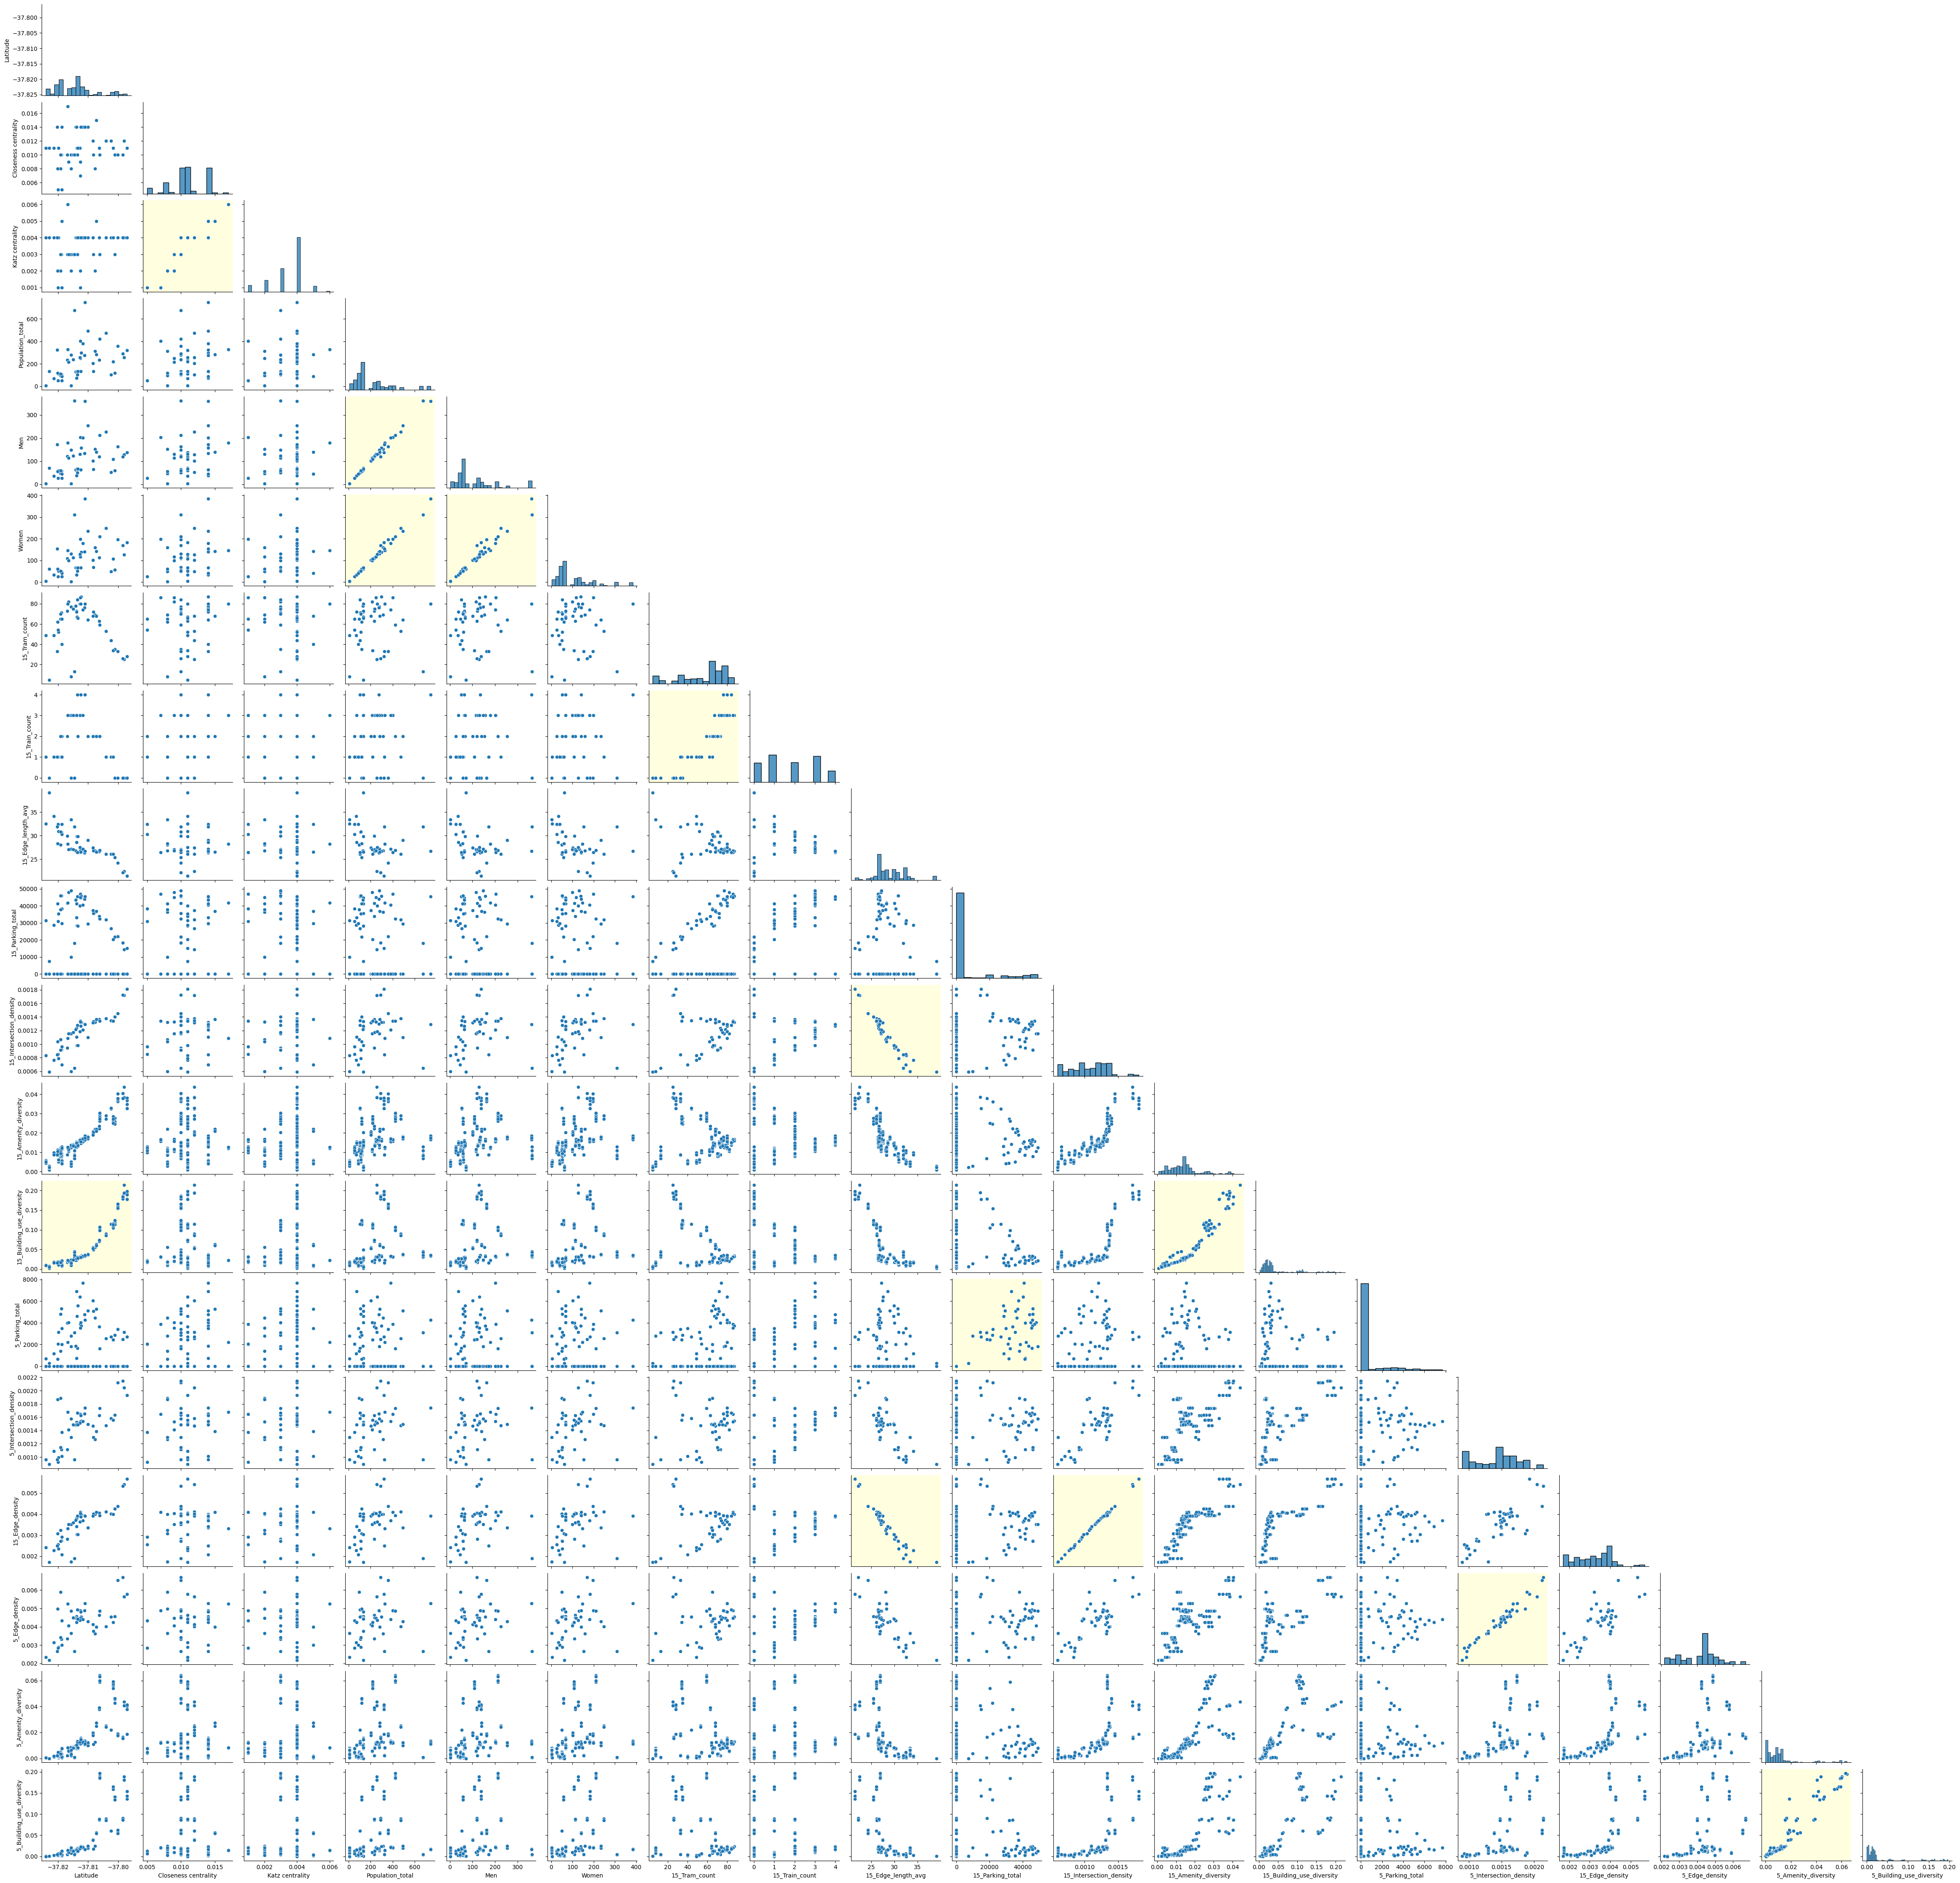

In [58]:
# Set the threshold for the absolute correlation value
threshold = 0.8

# Find columns with more than one absolute correlation value greater than the threshold
high_corr_columns = ck.columns[(ck.abs() > threshold).sum(axis=0) > 1].tolist()

print(f"Columns with more than one absolute correlation value greater than {threshold}:")
for col in high_corr_columns:
    print(col)
subset_columns = high_corr_columns

# Sample the data to reduce size
sampled_df = mel_df_final[subset_columns].sample(n=1000, random_state=42)  # Adjust n as needed

# Create a pair plot
pair_plot = sns.pairplot(sampled_df)

# Highlight the combinations with absolute correlation value greater than the threshold
for i, col1 in enumerate(subset_columns):
    for j, col2 in enumerate(subset_columns):
        if i != j:
            if i > j:  # Only highlight the lower triangle
                if abs(ck.loc[col1, col2]) > threshold:
                    pair_plot.axes[i, j].set_facecolor('lightyellow')  # Change background color
            else:
                pair_plot.axes[i, j].set_visible(False)  # Hide the upper triangle

# Adjust the layout
plt.subplots_adjust(top=0.95)
plt.show()

In [59]:
var2keep = np.array(list(set(variables) - set(removed_variables)))

In [60]:
final_df = mel_df_final[var2keep]

In [61]:
print(len(final_df.columns))
final_df.columns

51


Index(['15_Tram_count', '15_Intersection_density', 'Building count',
       'Cloud_cover', 'Population_total', 'Youth', 'Betweenness centrality',
       'Day', 'Hour', 'Building view mean', '5_Edge_length_avg', 'Location_id',
       'Closeness centrality', 'Longitude', 'Total_precipitation',
       '5_Job_count', '5_Intersection_density', '5_Building_use_diversity',
       'Wind_speed', '15_Job_count', 'Road view mean', '5_Tram_count',
       '15_Bus_count', '5_Lamp_density', 'Pedestrian_count',
       '5_Total_transit_stop_count', 'Children', 'Year', '5_Bench_density',
       'Visual complexity mean', 'Temperature', '15_Dwelling_count',
       '5_Walkable_path_length', '5_Bus_count', '15_Green_area',
       '5_Green_area', 'Elderly', '5_Parking_total', 'Footprint mean', 'Month',
       '15_Total_transit_stop_count', '15_Building_use_diversity', 'Day_type',
       '15_Lamp_density', '15_Tree_density', '5_Dwelling_count',
       'Green view mean', 'Sky view mean', '15_Walkable_path_leng

In [62]:
final_df.to_csv(os.path.join(output_dir,'processed_melbourne_data_for_modeling.csv'),index=False)

### Sensor distribution visual

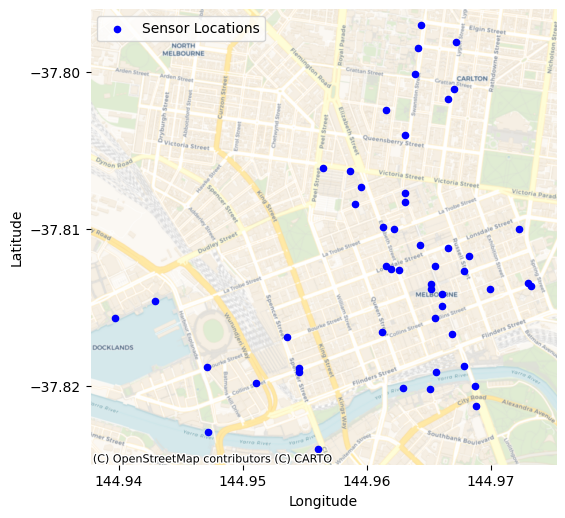

In [ ]:
# Create a new dataframe with unique Location_id and corresponding coordinates
unique_locations = mel_df_final.drop_duplicates(subset=['Location_id'])

# Convert the dataframe into a GeoDataFrame
geometry = [Point(xy) for xy in zip(unique_locations['Longitude'], unique_locations['Latitude'])]
geo_df = gpd.GeoDataFrame(unique_locations, geometry=geometry, crs="EPSG:4326")  # WGS84 CRS

# Plot the sensor locations on a map
fig, ax = plt.subplots(figsize=(6, 6))

# Plot the sensor locations in WGS84 (EPSG:4326) - natural lat/lon
geo_df.plot(ax=ax, color='blue', markersize=20, label='Sensor Locations')


# Convert a copy of the GeoDataFrame to Web Mercator (EPSG:3857) for basemap
geo_df_mercator = geo_df.to_crs(epsg=3857)

# Get the Web Mercator bounds (xmin, ymin, xmax, ymax)
minx, miny, maxx, maxy = geo_df_mercator.total_bounds

# Add basemap (contextily requires EPSG:3857)
# ctx.add_basemap(ax, crs=geo_df.crs, source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.9)
ctx.add_basemap(ax, crs=geo_df.crs, source=ctx.providers.CartoDB.Voyager)
# ctx.add_basemap(ax, crs=geo_df.crs, source=ctx.providers.Esri.WorldTopoMap, alpha=0.9)

# Manually set the x/y limits using original WGS84 data (not Web Mercator!)
ax.set_xlim(geo_df.total_bounds[0]-0.002, geo_df.total_bounds[2]+0.002)
ax.set_ylim(geo_df.total_bounds[1]-0.001, geo_df.total_bounds[3]+0.001)

# Reduce number of ticks and let Matplotlib pick "nice" values
ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=4, prune='both')) 
ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=3, prune='both'))

# Prevent scientific notation but keep natural decimal formatting
ax.xaxis.get_major_formatter().set_scientific(False)
ax.yaxis.get_major_formatter().set_scientific(False)
ax.xaxis.get_major_formatter().set_useOffset(False)
ax.yaxis.get_major_formatter().set_useOffset(False)
# Remove the frame (spines) of the plot
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.legend(loc="upper left", fontsize=10)
# plt.savefig(os.path.join(output_dir,'fig_02_sensor_locations_map.png'), dpi=1000, bbox_inches='tight')
plt.show()